# DRP: Counting cells from OME-Zarr

This notebook illustrates how to compute cell viabilities by combining `Feature tables` and `Condition tables` stored in the OME-Zarr images. We will use the leukemia PDX [demo dataset](https://fractal-demo.mls.uzh.ch/v2/projects/5/datasets/6) generated with the `drp_workflow.json`.
The dataset is available on https://fractal-demo.mls.uzh.ch/
Get a token to access it by logging in as a guest and use the "Get token" option in the user menu (top right).

In [1]:
from ngio import open_ome_zarr_container, open_ome_zarr_plate
from ngio.utils import fractal_fsspec_store
from dotenv import load_dotenv
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

### Load the HCS plate

In [ ]:
load_dotenv()
plate_url = "https://fractal-demo.mls.uzh.ch/data/files/srv/fractal/data/zarr/fractal/5_drug_profiling_leukemia/6_10x/18506825.zarr"
fractal_token = "" # Get this from https://fractal-demo.mls.uzh.ch/  
# store = fractal_fsspec_store(url=plate_url, fractal_token=os.getenv("fractal_token"))
store = fractal_fsspec_store(url=plate_url, fractal_token=fractal_token)
plate = open_ome_zarr_plate(store, parallel_safe=False)

### Aggregate features and conditions across OME-Zarr images
Collect features from all images and count cells.

In [ ]:
feature_table = plate.concatenate_image_tables("regionprops")  # remote feature concatenation can take a few minutes

In [5]:
cell_counts = feature_table.dataframe.groupby(
    ["row", "column", "BVC_test_data_CyQ_classifier_prediction"]
    ).size().reset_index().rename(columns={
        "column": "col", 
        0: "response", 
        "BVC_test_data_CyQ_classifier_prediction": "readout"
        }
    )


Collect conditions from all images and join with cell counts.

In [ ]:
condition_table = plate.concatenate_image_tables("condition")  # remote condition concatenation can take a few minutes

In [7]:
df = cell_counts.merge(condition_table.dataframe, on = ["row", "col"])

Normalize cell counts by DMSO vehicle control wells.

In [8]:
dmso_response = df.query('Drug == "DMSO"').groupby(["readout"]).agg(
    avg_dmso_response=('response', 'median')
)
df = df.merge(dmso_response, on = "readout")
df["norm_response"] = df["response"] / df["avg_dmso_response"]

Search for dose response of Venetoclax (BCL2 inhibitor).

In [9]:
df_ven = df.query('Drug == "Venetoclax" and readout == "live leukemia"')
df_ven

,row,col,readout,response,Drug,Concentration,Concentration unit,column,path_in_well,avg_dmso_response,norm_response
47,C,5,live leukemia,3928,Venetoclax,0.125,nM,5,0,3718.5,1.056340
107,D,5,live leukemia,2927,Venetoclax,0.125,nM,5,0,3718.5,0.787145
167,E,5,live leukemia,3435,Venetoclax,1.000,nM,5,0,3718.5,0.923760
227,F,5,live leukemia,2585,Venetoclax,1.000,nM,5,0,3718.5,0.695173
287,G,5,live leukemia,2126,Venetoclax,12.500,nM,5,0,3718.5,0.571736
347,H,5,live leukemia,967,Venetoclax,12.500,nM,5,0,3718.5,0.260051
407,I,5,live leukemia,559,Venetoclax,100.000,nM,5,0,3718.5,0.150329
467,J,5,live leukemia,466,Venetoclax,100.000,nM,5,0,3718.5,0.125319
526,K,5,live leukemia,342,Venetoclax,1250.000,nM,5,0,3718.5,0.091973
586,L,5,live leukemia,232,Venetoclax,1250.000,nM,5,0,3718.5,0.062391


In [18]:
# Save the dataframe for later use
df_ven.to_csv("dataset/viability_measurements_venetoclax.csv", index=False)

Text(0, 0.5, 'viability')

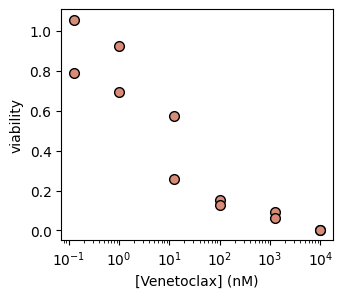

In [10]:
fig, ax = plt.subplots(1,1, figsize=(3.5,3))
plt.rcParams["font.family"] = "Arial"
ax.plot(df_ven["Concentration"], df_ven["norm_response"], "o", mec="black", mfc="#d78b78", markersize=7)
ax.set_xscale('log')
ax.set_xlabel('[Venetoclax] (nM)')
ax.set_ylabel('viability')

*Note*: To interpret the DRP profiles, the dose-response of each drug will be z-scored against the patient cohort as visualized in the [DRP Figure](Fig_DRP.md).

#### Load representative images

In [11]:
metadata = {
    "ven_low": "Venetoclax 0.125 nM",
    "ven_high": "Venetoclax 100 nM"
    }

In [12]:
ome_zarr_container = dict()
ome_zarr_container["ven_low"] = plate.get_image("C", "5", "0")
ome_zarr_container["ven_high"] = plate.get_image("I", "5", "0")

In [13]:
rois = dict()
rois["ven_low"] = ome_zarr_container["ven_low"].get_roi_table("FOV_ROI_table").rois()
rois["ven_high"] = ome_zarr_container["ven_high"].get_roi_table("FOV_ROI_table").rois()

In [14]:
img = dict()
img["ven_low"]  = ome_zarr_container["ven_low"].get_image().get_as_numpy(channel_selection = "CyQuant", z=0)
img["ven_high"]  = ome_zarr_container["ven_high"].get_image().get_as_numpy(channel_selection = "CyQuant", z=0)

In [15]:
img_roi = dict()
img_roi["ven_low"] = ome_zarr_container["ven_low"].get_image().get_roi_as_numpy(rois["ven_low"][0], channel_selection = "CyQuant", z=0)
img_roi["ven_high"]  = ome_zarr_container["ven_high"].get_image().get_roi_as_numpy(rois["ven_high"][0], channel_selection = "CyQuant", z=0)

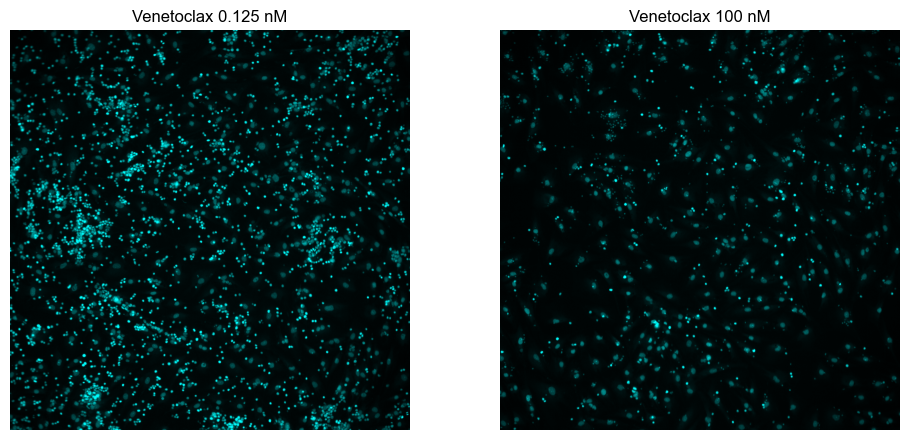

In [16]:
cyan_cmap = LinearSegmentedColormap.from_list('cyan', ['black', 'cyan'])
max_int = 8000

fig, axs = plt.subplots(1,2, figsize=(10,4.5))
for ax,(key,roi),(_,meta) in zip(axs, img_roi.items(), metadata.items()):
    ax.imshow(roi, cmap = cyan_cmap, vmax = max_int)
    ax.axis("off")
    ax.title.set_text(meta)
plt.tight_layout()